# 4 — With and without VirtualiZarr: what it actually costs

Notebooks [1](1_test_virtualizarr.ipynb)–[3](3_real_example_pipeline.ipynb) established that a
virtual NISAR cube works and produces a defensible signal. This one asks the question a colleague
deciding whether to bother would ask: **how much faster is it, and how much less data moves?**

One analysis — the Paradise field backscatter median over the full track — run eight ways:

| | Path | Where |
|---|---|---|
| **A** | Icechunk virtual cube, direct S3 | measured here, in-region |
| **B** | Open each HDF5 granule, direct S3 (`s3fs`) | measured here, in-region |
| **C** | Open each HDF5 granule over HTTPS (`fsspec`) | measured here, in-region |
| **C′** | The same, with the fsspec block aligned to NISAR's 1 MB chunk | measured here, in-region |
| **D** | `earthaccess.open()` — the idiomatic library call | measured here, in-region |
| **D′** | `earthaccess.open()` with its block cache aligned to NISAR's chunk size | measured here, in-region |
| **F** | `earthaccess.virtualize()` — a virtual cube built per session, never saved | measured here, in-region |
| **E** | Download the granules first, then analyse | modelled from file sizes |

Discovery is compared too: `earthaccess` against `asf_search`, since finding the granules is a
cost every path pays before it can read anything.

## What "local" means in this notebook, and what it doesn't

This platform (CryoCloud) runs in AWS **us-west-2** — the same region as the NISAR archive. So
every path here is measured with a fast, low-latency link to the data. That makes A, B and C an
honest comparison *with each other*, and it makes none of them a measurement of what a laptop
would experience.

Off-AWS users differ in two ways. First, **they cannot use direct S3 at all** — the credentials
are region-scoped, so they are forced onto the HTTPS endpoint. Path C measures exactly that
protocol switch, in isolation, with the network held constant. Second, they have a slower, higher
latency link. That part cannot be measured from here, so section 10 **models** it arithmetically
from the measured byte counts and request counts, with the assumptions written down. A model is
labelled as a model everywhere it appears.

In [1]:
import sys, time, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, ".")

from pathlib import Path
import numpy as np, pandas as pd, geopandas as gpd, xarray as xr
import h5py, s3fs, rioxarray  # noqa: F401
import matplotlib.pyplot as plt, matplotlib as mpl
import re
import icechunk, earthaccess
import asf_search as asf
from virtualizarr.parsers import HDFParser
import nisar_virtual as nv

icechunk.set_logs_filter("error")
nv.earthaccess.login(strategy="netrc")

EPSG = 32610
GEOM = Path("/home/jovyan/repos/nisar/geometries")
REPO_PATH = Path.home() / "nisar_cubes" / "rainier_gcov"
SUMMIT = (-121.7603, 46.8523)
BBOX = (SUMMIT[0] - 0.1807, SUMMIT[1] - 0.1050, SUMMIT[0] + 0.1807, SUMMIT[1] + 0.1050)

field_gdf = gpd.read_file(GEOM / "paradise_road_loop_snow_field.geojson")
north_gdf = gpd.read_file(GEOM / "snotel_field_north.geojson")

SURFACE, INK, INK2 = "#fcfcfb", "#0b0b0b", "#52514e"
CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK2, "axes.edgecolor": "#d8d7d2",
    "xtick.color": INK2, "ytick.color": INK2,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": "#ecebe7", "grid.linewidth": 0.8,
    "font.size": 10, "axes.titlesize": 11, "figure.dpi": 120, "legend.frameon": False,
})
RESULTS = {}
print("ready")

from pathlib import Path
FIG = Path("figures"); FIG.mkdir(exist_ok=True)   # figures referenced from the README


ready


---
## 1. The task, defined once

Median HH γ⁰ over the north Paradise field, for every acquisition on descending track 065's
dominant output grid. A small AOI over a long series — the shape of analysis a virtual cube should
be good at, and the shape most snow and ice work actually has.

Both the S3 and HTTPS URL for each granule, so paths B and C read the *same bytes* over different
protocols.

In [2]:
res = earthaccess.search_data(short_name="NISAR_L2_GCOV_PROVISIONAL_V1",
                              bounding_box=BBOX, count=200)
pairs, GRANULE = [], {}
for g in res:
    direct = [u for u in g.data_links(access="direct") if u.endswith(".h5")]
    over_https = [u for u in g.data_links() if u.endswith(".h5")]
    if direct and over_https:
        name = direct[0].rsplit("/", 1)[-1]
        if "_172_" in name and "_D_065_" in name:      # the dominant grid, track 065 D
            pairs.append((direct[0], over_https[0]))
            GRANULE[direct[0]] = g                     # for earthaccess.open() later
# The archive holds more than one product version of some takes. Left in, path B
# would open 24 files to produce 23 distinct dates while path A read 23 - and the
# benchmark would be quietly unfair. Keep the highest version per acquisition.
import re
VER, STAMP = re.compile(r"_(\d{3})\.h5$"), re.compile(r"_(\d{8}T\d{6})_")
best = {}
for d, h in sorted(set(pairs)):
    name = d.rsplit("/", 1)[-1]
    stamp = STAMP.search(name).group(1)
    version = int(m.group(1)) if (m := VER.search(name)) else 0
    if version >= best.get(stamp, (-1,))[0]:
        best[stamp] = (version, d, h)
raw = len(set(pairs))
pairs = [(d, h) for _, (_, d, h) in sorted(best.items())]
N = len(pairs)
print(f"{N} granules on track D 065's dominant grid "
      f"({raw - N} superseded product version(s) dropped)")
print(f"  s3    {pairs[0][0][:96]}")
print(f"  https {pairs[0][1][:96]}")

24 granules on track D 065's dominant grid (1 superseded product version(s) dropped)
  s3    s3://sds-n-cumulus-prod-nisar-products/NISAR_L2_GCOV_PROVISIONAL_V1/NISAR_L2_PR_GCOV_004_172_D_0
  https https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GCOV_PROVISIONAL_V1/NISAR_L2_PR_GCOV_00


In [3]:
# The AOI as a pixel window on that grid, so every path reads an identical region.
X0, Y0, PS = 334805.0, 5320075.0, 10.0          # grid origin and posting
minx, miny, maxx, maxy = field_gdf.to_crs(EPSG).total_bounds
PAD = 200
IX0 = int((minx - PAD - X0) // PS); IX1 = int((maxx + PAD - X0) // PS) + 1
IY0 = int((Y0 - (maxy + PAD)) // PS); IY1 = int((Y0 - (miny - PAD)) // PS) + 1
print(f"AOI window  y[{IY0}:{IY1}]  x[{IX0}:{IX1}]  = {IY1-IY0} x {IX1-IX0} px "
      f"({(IX1-IX0)*PS/1000:.2f} x {(IY1-IY0)*PS/1000:.2f} km)")

CHUNK = 512
CY = (IY0 // CHUNK, (IY1 - 1) // CHUNK)
CX = (IX0 // CHUNK, (IX1 - 1) // CHUNK)
print(f"which lands inside chunks y[{CY[0]}..{CY[1]}] x[{CX[0]}..{CX[1]}] "
      f"-> {(CY[1]-CY[0]+1) * (CX[1]-CX[0]+1)} chunks of {CHUNK}x{CHUNK} per granule")

AOI window  y[13777:13874]  x[26027:26126]  = 97 x 99 px (0.99 x 0.97 km)
which lands inside chunks y[26..27] x[50..51] -> 4 chunks of 512x512 per granule


### How much is this granule, and how much is the answer?

Worth having the two extremes on the table before measuring anything in between.

In [4]:
import obstore
registry = nv.obstore_registry()
sizes = []
for s3url, _ in pairs:
    st, p = registry.resolve(s3url)
    sizes.append(obstore.head(st, p)["size"])
GRANULE_BYTES = int(np.mean(sizes))
ARCHIVE_BYTES = int(np.sum(sizes))
ANSWER_BYTES = N * 8            # N float64 medians

print(f"one granule          : {GRANULE_BYTES/1e9:6.2f} GB")
print(f"all {N} granules      : {ARCHIVE_BYTES/1e9:6.1f} GB")
print(f"the answer we want   : {ANSWER_BYTES} bytes ({N} float64 medians)")
print(f"\nratio               : {ARCHIVE_BYTES/ANSWER_BYTES:,.0f}x more data than answer")

one granule          :   6.88 GB
all 24 granules      :  165.2 GB
the answer we want   : 192 bytes (24 float64 medians)

ratio               : 860,596,907x more data than answer


---
## 2. Finding the granules: `earthaccess` vs `asf_search`

Before any path can read a byte it has to know which files exist. Two libraries are in common use
for NISAR — `earthaccess` (NASA-wide, queries CMR) and `asf_search` (ASF's own API, and what the
reference notebook uses). They are worth timing side by side, if only to establish that discovery
is *not* where the cost is.

In [5]:
minx, miny, maxx, maxy = BBOX
wkt = (f"POLYGON(({minx} {miny},{maxx} {miny},{maxx} {maxy},"
       f"{minx} {maxy},{minx} {miny}))")

t0 = time.time()
ea_hits = earthaccess.search_data(short_name="NISAR_L2_GCOV_PROVISIONAL_V1",
                                  bounding_box=BBOX, count=200)
ea_time = time.time() - t0

t0 = time.time()
asf_hits = asf.search(intersectsWith=wkt, dataset=["NISAR"],
                      processingLevel=["GCOV"], maxResults=250)
asf_time = time.time() - t0

def on_our_track(name):
    return name.endswith(".h5") and "_172_" in name and "_D_065_" in name

ea_names = {u.rsplit("/", 1)[-1] for g in ea_hits
            for u in g.data_links(access="direct") if u.endswith(".h5")}
asf_names = {r.properties["fileName"] for r in asf_hits
             if r.properties["fileName"].endswith(".h5")}

print(f"{'library':14s} {'seconds':>8s} {'results':>8s} {'.h5 files':>10s} "
      f"{'on our track':>13s}")
for lib, secs, names in (("earthaccess", ea_time, ea_names),
                         ("asf_search", asf_time, asf_names)):
    print(f"{lib:14s} {secs:8.2f} {len(names):8d} {len(names):10d} "
          f"{sum(on_our_track(n) for n in names):13d}")

# Compare acquisitions, not filenames: the same take can appear more than once
# under different reprocessing ids, so filename counts are not comparable.
import re
STAMP_RE = re.compile(r"_(\d{8}T\d{6})_")
takes = lambda names: {STAMP_RE.search(n).group(1) for n in names if on_our_track(n)}
t_ea, t_asf = takes(ea_names), takes(asf_names)
print(f"\ndistinct acquisitions on our track — earthaccess {len(t_ea)}, "
      f"asf_search {len(t_asf)}")
print(f"  found only by asf_search : {sorted(t_asf - t_ea) or 0}")
print(f"  found only by earthaccess: {sorted(t_ea - t_asf) or 0}")

library         seconds  results  .h5 files  on our track
earthaccess        0.47       42         42            25
asf_search         0.41       65         65            34

distinct acquisitions on our track — earthaccess 24, asf_search 25
  found only by asf_search : ['20251029T031847']
  found only by earthaccess: 0


Both take well under a second, so **discovery is free relative to everything that follows** — the
expensive part is opening what you found, not finding it. Worth stating explicitly, because it
means the benchmark below measures the thing that actually matters.

They do not return the same thing, though. `asf_search` surfaces an acquisition that the CMR query
misses, and it surfaces multiple *reprocessing campaigns* of the same take where `earthaccess`
shows one. Neither is wrong — they are different indexes — but a pipeline that assumes they agree
will quietly index a different record depending on which library it used. The cube in this
notebook is built from the `earthaccess` list, so it is one acquisition short of what ASF knows
about; that is a bug to fix, not a property to rely on.

In [6]:
# asf_search exposes the reprocessing id (CRID) as metadata; earthaccess makes
# you parse it out of the filename. Both must be deduplicated, but only one of
# them hands you the key.
import re
STAMP_RE = re.compile(r"_(\d{8}T\d{6})_")

asf_ours = [r for r in asf_hits if on_our_track(r.properties["fileName"])]
by_take = {}
for r in asf_ours:
    stamp = STAMP_RE.search(r.properties["fileName"]).group(1)
    by_take.setdefault(stamp, []).append(r.properties["crid"])

dupes = {k: v for k, v in by_take.items() if len(v) > 1}
print(f"acquisitions on our track     : {len(by_take)}")
print(f"with more than one CRID       : {len(dupes)}")
for stamp, crids in dupes.items():
    print(f"   {stamp}  CRIDs {sorted(crids)}  -> keep {max(crids)}")
print(f"\nCRIDs present: "
      f"{dict(pd.Series([r.properties["crid"] for r in asf_ours]).value_counts())}")
print("\nasf_search hands you `crid` as metadata; with earthaccess you parse the")
print("filename yourself. Note there are TWO duplication axes here — the CRID")
print("(reprocessing campaign) and the trailing _NNN within a campaign — and")
print("`max(crid)` is the convention the reference notebook uses, not a")
print("documented ordering. Worth confirming with ASF before trusting it.")

acquisitions on our track     : 25
with more than one CRID       : 9
   20260720T031849  CRIDs ['P05023', 'P05023']  -> keep P05023
   20260708T031850  CRIDs ['P05023', 'P05023']  -> keep P05023
   20260626T031850  CRIDs ['P05023', 'P05023']  -> keep P05023
   20260109T031850  CRIDs ['P05023', 'X05009']  -> keep X05009
   20251228T031850  CRIDs ['P05023', 'X05009']  -> keep X05009
   20251216T031849  CRIDs ['P05023', 'X05009']  -> keep X05009
   20251204T031849  CRIDs ['P05023', 'X05009']  -> keep X05009
   20251122T031848  CRIDs ['P05023', 'X05009']  -> keep X05009
   20251110T031848  CRIDs ['P05023', 'X05009']  -> keep X05009

CRIDs present: {'P05023': np.int64(27), 'X05009': np.int64(7)}

asf_search hands you `crid` as metadata; with earthaccess you parse the
filename yourself. Note there are TWO duplication axes here — the CRID
(reprocessing campaign) and the trailing _NNN within a campaign — and
`max(crid)` is the convention the reference notebook uses, not a
documented ordering. 

---
## 3. Instrumentation

Two different accounting methods, and it matters which is which.

**Paths B and C** are measured at the reader: fsspec fetches byte ranges through its cache, so
patching the cache's fetcher counts every byte that actually crossed the network, and every
request that carried it. Note the patch has to go on `cache.fetcher` — the cache captured the
bound method at construction, so patching `_fetch_range` on the file object does nothing (a
mistake worth recording, because it silently reports zero).

**Path A** is computed from the chunk manifest: the byte lengths of exactly those chunks the AOI
intersects. Icechunk fetches them from Rust, where a Python counter cannot reach. The manifest is
the authoritative record of what has to be read, so this is exact rather than approximate — but it
is arithmetic, not observation, and it is labelled that way in the results.

In [7]:
def counting(f):
    # fsspec's cache holds the fetcher it was constructed with, so patch it there.
    stats = {"bytes": 0, "requests": 0}
    original = f.cache.fetcher
    def counted(start, end):
        data = original(start, end)
        stats["bytes"] += len(data); stats["requests"] += 1
        return data
    f.cache.fetcher = counted
    return stats

BLOCK = 4 * 2**20      # fsspec read-ahead block; see section 7 for the sensitivity

def s3_filesystem():
    c = nv.nisar_s3_credentials()
    return s3fs.S3FileSystem(key=c["accessKeyId"], secret=c["secretAccessKey"],
                             token=c["sessionToken"], anon=False,
                             client_kwargs={"region_name": nv.REGION})

def median_from_window(arr):
    return float(np.nanmedian(np.where(arr > 0, arr, np.nan)))

---
## 4. Path A — the virtual cube

The cube from notebook 3, already built. This is the steady state: the index exists, and every
analysis from here is a read.

In [8]:
# The archive gains an acquisition every 12 days; keep the notebook-3 cube
# current so every path below measures the same set of granules. append_new is
# idempotent - on a cube that is already current it is a no-op.
DENY = ["inputDataExceptionMask", "listOfCovarianceTerms", "listOfPolarizations", "mask",
        "numberOfLooks", "numberOfSubSwaths", "rtcGammaToSigmaFactor",
        "xCoordinateSpacing", "yCoordinateSpacing"]
STAMP = re.compile(r"_(\d{8}T\d{6})_")
t0 = time.time()
_snap, appended = nv.append_new(nv.open_repo(REPO_PATH),
                                [(STAMP.search(d).group(1), d) for d, _ in pairs],
                                drop_variables=DENY, workers=1)
print(f"cube brought current: {len(appended)} acquisition(s) appended in {time.time()-t0:.1f}s\n")

def path_a():
    cube = nv.open_cube(nv.open_repo(REPO_PATH))
    x, y = cube.xCoordinates.values, cube.yCoordinates.values
    sub = cube.HHHH.isel(yCoordinates=slice(IY0, IY1), xCoordinates=slice(IX0, IX1))
    db = 10 * np.log10(sub.where(sub > 0))
    med = db.median(dim=("yCoordinates", "xCoordinates"), skipna=True).compute()
    return pd.Series(med.values, index=cube.time.to_index())

t0 = time.time()
a_series = path_a()
a_time = time.time() - t0

# bytes: the manifest's own record of the chunks this AOI intersects
import virtualizarr as vz
from virtualizarr.parsers import HDFParser
man = vz.open_virtual_dataset(pairs[0][0], registry=registry,
                              parser=HDFParser(group=nv.GCOV_GRIDS))["HHHH"].data.manifest
# `_lengths` is private; there is no public accessor for the whole array
per_granule = int(man._lengths[CY[0]:CY[1]+1, CX[0]:CX[1]+1].sum())
a_bytes = per_granule * len(a_series)
a_requests = (CY[1]-CY[0]+1) * (CX[1]-CX[0]+1) * len(a_series)

RESULTS["A · virtual cube, direct S3"] = dict(
    seconds=a_time, bytes=a_bytes, requests=a_requests, short="A  virtual cube · S3", color="#2a78d6",
    measured="time measured; bytes from manifest")
print(f"{len(a_series)} dates in {a_time:.2f}s")
print(f"chunk bytes for the AOI : {a_bytes/1e6:.1f} MB "
      f"({per_granule/1e6:.2f} MB x {len(a_series)} granules)")
print(f"range requests implied  : {a_requests}")
print(f"\n{a_series.round(2).to_string()}")

cube brought current: 1 acquisition(s) appended in 3.4s



24 dates in 2.24s
chunk bytes for the AOI : 63.4 MB (2.64 MB x 24 granules)
range requests implied  : 96

time
2025-11-10 03:18:48   -3.59
2025-11-22 03:18:48   -4.36
2025-12-04 03:18:49   -5.79
2025-12-16 03:18:49   -4.06
2025-12-28 03:18:50   -6.57
2026-01-09 03:18:50   -6.48
2026-01-21 03:18:51   -4.59
2026-02-02 03:18:52   -5.07
2026-02-14 03:18:52   -5.71
2026-02-26 03:18:53   -6.48
2026-03-10 03:18:53   -6.80
2026-03-22 03:18:53   -5.87
2026-04-03 03:18:54   -6.15
2026-04-15 03:18:54   -6.06
2026-04-27 03:18:54   -4.58
2026-05-09 03:18:53   -4.48
2026-05-21 03:18:53   -4.39
2026-06-02 03:18:52   -3.98
2026-06-14 03:18:51   -3.76
2026-06-26 03:18:50   -4.59
2026-07-08 03:18:50   -4.27
2026-07-20 03:18:49   -4.55
2026-08-13 03:18:48   -4.66
2026-08-25 03:18:47   -4.47


### 4.1 The same cube, without S3

Everything above assumes direct S3. That is fine in-region, but off-AWS the credentials do not
work at all — so the interesting question is whether a virtual cube can be *built and read over
HTTPS instead*, or whether virtualization is an in-region-only technique.

Nothing about the manifest requires S3. A chunk reference is a URL, an offset and a length, and
Icechunk has an `http_store` container to resolve `https://` prefixes. The only real question is
authentication: the DAAC's HTTPS endpoint redirects to Earthdata Login.

In [9]:
from obstore.store import HTTPStore
from obspec_utils.registry import ObjectStoreRegistry
import virtualizarr as vz
from concurrent.futures import ThreadPoolExecutor

HOST = "https://nisar.asf.earthdatacloud.nasa.gov"
TOKEN = earthaccess.login(strategy="netrc").token
HEADERS = {"Authorization": f"Bearer {TOKEN['access_token']}"}
print(f"EDL bearer token expires {TOKEN['expiration_date']} — "
      f"unlike the 1-hour S3 credentials, so static headers are workable")

DROP = nv.drop_outside(["HHHH", "HVHV", "xCoordinates", "yCoordinates", "projection",
                        "mask", "numberOfLooks", "rtcGammaToSigmaFactor",
                        "inputDataExceptionMask", "listOfCovarianceTerms",
                        "listOfPolarizations", "numberOfSubSwaths",
                        "xCoordinateSpacing", "yCoordinateSpacing"])

http_registry = ObjectStoreRegistry(
    {HOST: HTTPStore.from_url(HOST, client_options={"default_headers": HEADERS})})
parser = HDFParser(group=nv.GCOV_GRIDS, drop_variables=DROP)

def build_one(url):
    return vz.open_virtual_dataset(url, registry=http_registry, parser=parser)

# Threads help here, unlike over S3. Over S3 the build is ~50% pure-Python URI
# validation holding the GIL; over HTTPS the network wait dominates, so the
# bottleneck moved and the GIL stops mattering.
t0 = time.time()
with ThreadPoolExecutor(8) as ex:
    vdss = list(ex.map(build_one, [h for _, h in pairs]))
build_https = time.time() - t0
print(f"\n{len(vdss)} manifests over HTTPS in {build_https:.1f}s "
      f"({build_https/len(vdss):.2f}s each, 8 threads)")

EDL bearer token expires 09/27/2026 — unlike the 1-hour S3 credentials, so static headers are workable



24 manifests over HTTPS in 89.8s (3.74s each, 8 threads)


In [10]:
import shutil
HTTPS_REPO = Path.home() / "nisar_cubes" / "rainier_gcov_https"
if HTTPS_REPO.exists():
    shutil.rmtree(HTTPS_REPO)

cfg = icechunk.RepositoryConfig.default()
cfg.set_virtual_chunk_container(
    icechunk.VirtualChunkContainer(HOST + "/", icechunk.http_store(headers=HEADERS)))
repo_https = icechunk.Repository.create(
    storage=icechunk.local_filesystem_storage(str(HTTPS_REPO)),
    config=cfg,
    # the explicit sentinel; passing None here is deprecated
    authorize_virtual_chunk_access={HOST + "/": icechunk.Credentials.HttpAccess()})

STAMP = re.compile(r"_(\d{8}T\d{6})_")
members = sorted((STAMP.search(h).group(1), h, v) for (_, h), v in zip(pairs, vdss))
sess = repo_https.writable_session("main")
nv.concat_cube(members).vz.to_icechunk(sess.store)
sess.commit(f"HTTPS-referenced cube: {len(members)} acquisitions")
print(f"committed; index {sum(f.stat().st_size for f in HTTPS_REPO.rglob('*') if f.is_file())/1e6:.1f} MB")

committed; index 5.1 MB


In [11]:
def path_a_https():
    cube = xr.open_zarr(repo_https.readonly_session("main").store,
                        consolidated=False, zarr_format=3, chunks={})
    sub = cube.HHHH.isel(yCoordinates=slice(IY0, IY1), xCoordinates=slice(IX0, IX1))
    db = 10 * np.log10(sub.where(sub > 0))
    med = db.median(dim=("yCoordinates", "xCoordinates"), skipna=True).compute()
    return pd.Series(med.values, index=cube.time.to_index())

t0 = time.time()
ah_series = path_a_https()
ah_time = time.time() - t0

man_h = vdss[0]["HHHH"].data.manifest
ah_bytes = int(man_h._lengths[CY[0]:CY[1]+1, CX[0]:CX[1]+1].sum()) * len(ah_series)
ah_requests = (CY[1]-CY[0]+1) * (CX[1]-CX[0]+1) * len(ah_series)

RESULTS["A′ · virtual cube, HTTPS"] = dict(
    seconds=ah_time, bytes=ah_bytes, requests=ah_requests,
    short="A′ virtual cube · HTTPS", color="#86b6ef",
    measured="time measured; bytes from manifest")

print(f"{len(ah_series)} dates in {ah_time:.2f}s")
print(f"bytes {ah_bytes/1e6:.1f} MB (identical chunks to path A: {ah_bytes == a_bytes})")
print(f"same answer as path A: "
      f"{np.allclose(a_series.reindex(ah_series.index), ah_series, atol=1e-9)}")
print(f"\nvs path A over S3: {ah_time/a_time:.1f}x wall time, same bytes")

24 dates in 12.29s
bytes 63.4 MB (identical chunks to path A: True)
same answer as path A: True

vs path A over S3: 5.5x wall time, same bytes


**It works.** A virtual cube is not an in-region-only technique: the manifest holds `https://`
URLs, `icechunk.http_store` resolves them with an Earthdata bearer token, and the pixels come back
identical to the S3 path. Two things are worth recording.

**The bottleneck moves, and so does the right parallelism.** Building over HTTPS is much slower per
granule than over S3, but it responds to *threads* — which the S3 build does not (README, "On
parallelizing the build"). Over S3 roughly half the build is pure-Python URI validation holding the
GIL; over HTTPS the network wait dominates and the GIL stops mattering. Same code, opposite advice.

**Authentication is easier here than for S3, not harder.** The EDL bearer token above is good for
weeks, where the S3 credentials expire hourly and need the refreshable-callable dance of failure
#5. `icechunk.http_store` takes static headers and that is genuinely sufficient — though a job
running longer than the token's life still needs to re-issue it, and there is no refresh hook.

---
## 5. Path B — open every granule, direct S3

No virtualization. What the same analysis costs when each session opens all 22 files itself. This
is the honest baseline for someone already on AWS: the comparison is not "virtual versus
downloading", it is "virtual versus the normal in-region way".

In [12]:
def path_b(urls, fs):
    out, tb, tr = {}, 0, 0
    for i, url in enumerate(urls, 1):
        f = fs.open(url, "rb", block_size=BLOCK)
        st = counting(f)
        try:
            with h5py.File(f, "r") as h:
                win = h[f"{nv.GCOV_GRIDS}/HHHH"][IY0:IY1, IX0:IX1]
                stamp = h["/science/LSAR/identification/zeroDopplerStartTime"][()]
        finally:
            f.close()
        stamp = stamp.decode() if isinstance(stamp, bytes) else str(stamp)
        out[pd.to_datetime(stamp[:19])] = 10 * np.log10(median_from_window(win))
        tb += st["bytes"]; tr += st["requests"]
        if i % 5 == 0 or i == len(urls):
            print(f"  {i}/{len(urls)}  {tb/1e6:7.0f} MB, {tr} requests")
    return pd.Series(out).sort_index(), tb, tr

s3 = s3_filesystem()
t0 = time.time()
b_series, b_bytes, b_requests = path_b([d for d, _ in pairs], s3)
b_time = time.time() - t0

RESULTS["B · one HDF5 at a time, direct S3"] = dict(
    seconds=b_time, bytes=b_bytes, requests=b_requests,
    short="B  every HDF5 · S3", color="#eb6834", measured="measured")
print(f"\n{len(b_series)} dates in {b_time:.1f}s  "
      f"({b_time/len(b_series):.1f}s per granule)")
print(f"bytes over the network  : {b_bytes/1e6:.0f} MB")
print(f"range requests          : {b_requests}")

  5/24      237 MB, 55 requests


  10/24      475 MB, 110 requests


  15/24      712 MB, 165 requests


  20/24      949 MB, 220 requests


  24/24     1139 MB, 264 requests

24 dates in 26.7s  (1.1s per granule)
bytes over the network  : 1139 MB
range requests          : 264


---
## 6. Do the paths agree?

A benchmark that compares two different answers is measuring nothing.

In [13]:
common = a_series.index.intersection(b_series.index)
comp = pd.DataFrame({"virtual (A)": a_series.reindex(common),
                     "direct  (B)": b_series.reindex(common)})
comp["Δ dB"] = comp["virtual (A)"] - comp["direct  (B)"]
print(comp.round(4).to_string())
print(f"\nmatched dates    : {len(common)} of {len(a_series)} / {len(b_series)}")
print(f"max |difference| : {comp['Δ dB'].abs().max():.2e} dB")
print(f"identical        : {np.allclose(comp['virtual (A)'], comp['direct  (B)'], atol=1e-9)}")

                     virtual (A)  direct  (B)  Δ dB
2025-11-10 03:18:48      -3.5945      -3.5945  -0.0
2025-11-22 03:18:48      -4.3567      -4.3567  -0.0
2025-12-04 03:18:49      -5.7877      -5.7877  -0.0
2025-12-16 03:18:49      -4.0600      -4.0600  -0.0
2025-12-28 03:18:50      -6.5697      -6.5697   0.0
2026-01-09 03:18:50      -6.4765      -6.4765  -0.0
2026-01-21 03:18:51      -4.5892      -4.5892  -0.0
2026-02-02 03:18:52      -5.0720      -5.0720  -0.0
2026-02-14 03:18:52      -5.7105      -5.7105  -0.0
2026-02-26 03:18:53      -6.4787      -6.4787  -0.0
2026-03-10 03:18:53      -6.7999      -6.7999  -0.0
2026-03-22 03:18:53      -5.8714      -5.8714  -0.0
2026-04-03 03:18:54      -6.1487      -6.1487  -0.0
2026-04-15 03:18:54      -6.0575      -6.0575   0.0
2026-04-27 03:18:54      -4.5772      -4.5772  -0.0
2026-05-09 03:18:53      -4.4848      -4.4848  -0.0
2026-05-21 03:18:53      -4.3940      -4.3940  -0.0
2026-06-02 03:18:52      -3.9840      -3.9840  -0.0
2026-06-14 0

---
## 7. Path C — the same thing over HTTPS

Off-AWS users cannot use direct S3: the credentials are region-scoped. They go through the DAAC's
HTTPS endpoint instead. Measuring that here, from inside the region, isolates the cost of the
protocol switch from the cost of a slower network — the network is the same as path B's.

In [14]:
https = earthaccess.get_fsspec_https_session()
t0 = time.time()
c_series, c_bytes, c_requests = path_b([h for _, h in pairs], https)
c_time = time.time() - t0

RESULTS["C · one HDF5 at a time, HTTPS"] = dict(
    seconds=c_time, bytes=c_bytes, requests=c_requests,
    short="C  every HDF5 · HTTPS", color="#1baf7a", measured="measured")
print(f"\n{len(c_series)} dates in {c_time:.1f}s ({c_time/len(c_series):.1f}s per granule)")
print(f"bytes {c_bytes/1e6:.0f} MB, {c_requests} requests")
print(f"\nagrees with path A: "
      f"{np.allclose(a_series.reindex(c_series.index), c_series, atol=1e-9)}")
print(f"HTTPS vs direct S3: {c_time/b_time:.2f}x wall time, "
      f"{c_bytes/b_bytes:.2f}x bytes")

  5/24      237 MB, 55 requests


  10/24      475 MB, 110 requests


  15/24      712 MB, 165 requests


  20/24      949 MB, 220 requests


  24/24     1139 MB, 264 requests

24 dates in 75.5s (3.1s per granule)
bytes 1139 MB, 264 requests

agrees with path A: True
HTTPS vs direct S3: 2.83x wall time, 1.00x bytes


### 7.1 Path C′ — HTTPS with the block aligned to the chunk

Path C uses the same 4 MB fsspec block as B. Section 8.1 will show that a 1 MB block — one NISAR
chunk — is the right size for this access pattern; the same fix applies over HTTPS, and it is the
configuration an off-AWS user reading granule-at-a-time should actually use.

In [15]:
_BLOCK_SAVE, BLOCK = BLOCK, 1 * 2**20
t0 = time.time()
cp_series, cp_bytes, cp_requests = path_b([h for _, h in pairs], https)
cp_time = time.time() - t0
BLOCK = _BLOCK_SAVE

RESULTS["C′ · one HDF5 at a time, HTTPS, 1 MB blocks"] = dict(
    seconds=cp_time, bytes=cp_bytes, requests=cp_requests,
    short="C′ every HDF5 · HTTPS · 1 MB", color="#7fd0b0", measured="measured")
print(f"\n{len(cp_series)} dates in {cp_time:.1f}s ({cp_time/len(cp_series):.1f}s per granule)")
print(f"bytes {cp_bytes/1e6:.0f} MB, {cp_requests} requests")
print(f"agrees with path A: {np.allclose(a_series.reindex(cp_series.index), cp_series, atol=1e-9)}")
print(f"\nvs C (4 MB blocks): {cp_time/c_time:.2f}x wall time, {cp_bytes/c_bytes:.2f}x bytes")
print(f"vs A′ (HTTPS cube): {cp_time/ah_time:.1f}x wall time, {cp_bytes/ah_bytes:.1f}x bytes")

  5/24       70 MB, 60 requests


  10/24      139 MB, 120 requests


  15/24      209 MB, 180 requests


  20/24      278 MB, 240 requests


  24/24      334 MB, 288 requests

24 dates in 70.7s (2.9s per granule)
bytes 334 MB, 288 requests
agrees with path A: True

vs C (4 MB blocks): 0.94x wall time, 0.29x bytes
vs A′ (HTTPS cube): 5.7x wall time, 5.3x bytes


### How much of path B and C's volume is the read-ahead block?

Both move far more than the AOI's chunks require, and part of that is fsspec reading whole blocks.
Re-running two granules at a smaller block size separates the block overshoot from the HDF5
metadata traversal that is irreducible.

In [16]:
probe = [d for d, _ in pairs][:2]
for bs in (1 * 2**20, 4 * 2**20, 16 * 2**20):
    tb = tr = 0
    t0 = time.time()
    for url in probe:
        f = s3.open(url, "rb", block_size=bs)
        st = counting(f)
        try:
            with h5py.File(f, "r") as h:
                h[f"{nv.GCOV_GRIDS}/HHHH"][IY0:IY1, IX0:IX1]
        finally:
            f.close()
        tb += st["bytes"]; tr += st["requests"]
    print(f"block {bs//2**20:2d} MB : {tb/len(probe)/1e6:6.1f} MB and "
          f"{tr//len(probe):3d} requests per granule, {(time.time()-t0)/len(probe):.1f}s each")
print(f"\nthe AOI's chunks themselves : {per_granule/1e6:6.2f} MB per granule")
print("everything above that is HDF5 B-tree traversal plus block overshoot —")
print("re-paid on every granule, in every session.")

block  1 MB :   11.8 MB and  10 requests per granule, 0.7s each


block  4 MB :   43.3 MB and  10 requests per granule, 0.7s each


block 16 MB :  167.6 MB and  10 requests per granule, 2.3s each

the AOI's chunks themselves :   2.64 MB per granule
everything above that is HDF5 B-tree traversal plus block overshoot —
re-paid on every granule, in every session.


---
## 8. Path D — `earthaccess.open()`

Paths B and C are hand-rolled: an `s3fs` or `fsspec` filesystem opened explicitly. Most people
would not write that. They would write `earthaccess.open(granules)`, which is one line and picks
the access method for you — direct S3 when it detects it is in-region, HTTPS when it is not.

Measuring it matters for the benchmark's honesty: if the idiomatic call is much slower than
path B, then B was a strawman and the comparison against the virtual cube is unfair.

In [17]:
def path_earthaccess(urls):
    out, tb, tr = {}, 0, 0
    handles = earthaccess.open([GRANULE[u] for u in urls], show_progress=False)
    for i, f in enumerate(handles, 1):
        st = counting(f)
        try:
            with h5py.File(f, "r") as h:
                win = h[f"{nv.GCOV_GRIDS}/HHHH"][IY0:IY1, IX0:IX1]
                stamp = h["/science/LSAR/identification/zeroDopplerStartTime"][()]
        finally:
            f.close()
        stamp = stamp.decode() if isinstance(stamp, bytes) else str(stamp)
        out[pd.to_datetime(stamp[:19])] = 10 * np.log10(median_from_window(win))
        tb += st["bytes"]; tr += st["requests"]
        if i % 5 == 0 or i == len(handles):
            print(f"  {i}/{len(handles)}  {tb/1e6:7.0f} MB, {tr} requests")
    return pd.Series(out).sort_index(), tb, tr

t0 = time.time()
d_series, d_bytes, d_requests = path_earthaccess([u for u, _ in pairs])
d_time = time.time() - t0

RESULTS["D · earthaccess.open(), direct S3"] = dict(
    seconds=d_time, bytes=d_bytes, requests=d_requests,
    short="D  earthaccess.open()", color="#eda100", measured="measured")
print(f"\n{len(d_series)} dates in {d_time:.1f}s ({d_time/len(d_series):.1f}s per granule)")
print(f"bytes {d_bytes/1e6:.0f} MB, {d_requests} requests")
print(f"agrees with path A: "
      f"{np.allclose(a_series.reindex(d_series.index), d_series, atol=1e-9)}")
print(f"\nvs hand-rolled s3fs (B): {d_time/b_time:.2f}x wall time, "
      f"{d_bytes/b_bytes:.2f}x bytes")

  5/24      424 MB, 26 requests


  10/24      902 MB, 56 requests


  15/24     1334 MB, 83 requests


  20/24     1736 MB, 107 requests


  24/24     2089 MB, 129 requests

24 dates in 30.9s (1.3s per granule)
bytes 2089 MB, 129 requests
agrees with path A: True

vs hand-rolled s3fs (B): 1.16x wall time, 1.83x bytes


`earthaccess.open()` does resolve to direct S3 in-region — the same transport path B builds by
hand — but the two do **not** land in the same place. Across three runs today it took 0.9–1.5× B's
wall time and moved 1.8× the bytes in half as many requests: a larger read-ahead block, which trades
more data for fewer round trips. In-region that trade is a poor one, since bandwidth is plentiful
and latency is already low; off-AWS it would look better. (Wall times for the granule-at-a-time
paths moved by up to 1.8× between runs; byte and request counts did not move at all, which is why
the byte columns are the ones to trust.)

The conclusion for this benchmark is the reassuring one. Path B — hand-rolled `s3fs` with a 4 MB
block — is not a strawman; it is no slower and leaner than the idiomatic one-liner most people
would write. Measured against what a NISAR user would actually type, the virtual cube's advantage
is larger than the headline numbers, not smaller. Section 8.1 asks the fairer follow-up: what if
the idiomatic call is configured well?

### 8.1 Path D′ — the same call, with the cache tuned

The difference between B and D is not the transport, it is fsspec's cache. `earthaccess.open()`
picks a `blockcache` whose block size depends on *file size* — 4 MB under 100 MB, 8 MB under 1 GB,
**16 MB above 1 GB** (`earthaccess.store._optimal_fsspec_block_size`) — and every NISAR granule is
6.9 GB. That heuristic is tuned for ICESat-2-style files with hundreds of small datasets, where
metadata dominates; earthaccess's own [fsspec how-to](https://earthaccess.readthedocs.io/en/stable/user/howto/fsspec/)
says the right move is to *align the block size with the file's internal chunk size*. A NISAR
`HHHH` chunk is 512 × 512 float32, compressed — about 1 MB. So path D′ is path D with one keyword:
`open_kwargs={"cache_type": "blockcache", "block_size": 1 MB}`. The fair question for the benchmark
is whether a well-configured idiomatic call catches up with hand-rolled B — and how far it still is
from the virtual cube.

In [18]:
def path_earthaccess_tuned(urls, block_size=1 * 2**20):
    out, tb, tr = {}, 0, 0
    handles = earthaccess.open([GRANULE[u] for u in urls], show_progress=False,
                               open_kwargs={"cache_type": "blockcache", "block_size": block_size})
    for i, f in enumerate(handles, 1):
        st = counting(f)
        try:
            with h5py.File(f, "r") as h:
                win = h[f"{nv.GCOV_GRIDS}/HHHH"][IY0:IY1, IX0:IX1]
                stamp = h["/science/LSAR/identification/zeroDopplerStartTime"][()]
        finally:
            f.close()
        stamp = stamp.decode() if isinstance(stamp, bytes) else str(stamp)
        out[pd.to_datetime(stamp[:19])] = 10 * np.log10(median_from_window(win))
        tb += st["bytes"]; tr += st["requests"]
        if i % 5 == 0 or i == len(handles):
            print(f"  {i}/{len(handles)}  {tb/1e6:7.0f} MB, {tr} requests")
    return pd.Series(out).sort_index(), tb, tr

t0 = time.time()
dt_series, dt_bytes, dt_requests = path_earthaccess_tuned([u for u, _ in pairs])
dt_time = time.time() - t0

RESULTS["D′ · earthaccess.open(), 1 MB blocks"] = dict(
    seconds=dt_time, bytes=dt_bytes, requests=dt_requests,
    short="D′ earthaccess.open() · 1 MB", color="#f4cd6a", measured="measured")
print(f"\n{len(dt_series)} dates in {dt_time:.1f}s ({dt_time/len(dt_series):.1f}s per granule)")
print(f"bytes {dt_bytes/1e6:.0f} MB, {dt_requests} requests")
print(f"agrees with path A: "
      f"{np.allclose(a_series.reindex(dt_series.index), dt_series, atol=1e-9)}")
print(f"\nvs default earthaccess.open() (D): {dt_time/d_time:.2f}x wall time, {dt_bytes/d_bytes:.2f}x bytes")
print(f"vs hand-rolled s3fs, 4 MB blocks (B): {dt_time/b_time:.2f}x wall time, {dt_bytes/b_bytes:.2f}x bytes")
print(f"vs the virtual cube (A):              {dt_time/a_time:.1f}x wall time, {dt_bytes/a_bytes:.1f}x bytes")

  5/24       39 MB, 37 requests


  10/24       79 MB, 75 requests


  15/24      116 MB, 111 requests


  20/24      154 MB, 147 requests


  24/24      185 MB, 176 requests

24 dates in 14.7s (0.6s per granule)
bytes 185 MB, 176 requests
agrees with path A: True

vs default earthaccess.open() (D): 0.48x wall time, 0.09x bytes
vs hand-rolled s3fs, 4 MB blocks (B): 0.55x wall time, 0.16x bytes
vs the virtual cube (A):              6.6x wall time, 2.9x bytes


One keyword halves the idiomatic call: **14.7 s and 185 MB against 30.9 s and 2,089 MB** — an
11× cut in bytes moved, and now *faster and leaner than hand-rolled `s3fs` with 4 MB blocks* (path B).
The lesson generalises: for a chunked raster, `earthaccess.open()`'s file-size heuristic is the
wrong knob, and the `block_size` that matches the file's chunk is the right one. Anyone reading
NISAR granule-at-a-time should set it.

It does not close the gap. D′ still moves **2.9× the bytes the answer needs and takes 6.6× as long**
as the virtual cube, because the cost it cannot tune away is the one the cube removes: reassembling
each file's HDF5 metadata before the first pixel can be located. A 1 MB block still reads a 1 MB
block to fetch a 200-byte B-tree node, and it does so for every granule, every session. The cube
paid that once.

### 8.2 Path F — `earthaccess.virtualize()`: the index without the repository

earthaccess 0.18 added [`virtualize()`](https://earthaccess.readthedocs.io/en/stable/api/#earthaccess.virtual.virtualize),
which does what notebook 1 did by hand: build VirtualiZarr manifests for a list of granules, over S3
(`access="direct"`) or HTTPS (`"indirect"`), with credentials handled. It defaults to NASA's DMR++
sidecars, which NISAR does not have, so it falls back to `HDFParser` — and it must be scoped to a
group and given the deny-list, or it returns an empty dataset. It is the right tool for a one-off:
a virtual cube that lives for the session and is never written down. Its cost is the index build
*plus* the read, every time; path A paid the build once.

In [19]:
from virtualizarr.parsers import HDFParser as _HDFParser

t0 = time.time()
vds_f = earthaccess.virtualize(
    [GRANULE[u] for u, _ in pairs], access="direct", concat_dim="time",
    preprocess=lambda ds: ds.expand_dims("time"),
    parser=_HDFParser(group=nv.GCOV_GRIDS, drop_variables=DENY),
    coords="minimal", compat="override", parallel=False)
f_build = time.time() - t0
vds_f = vds_f.assign_coords(time=("time", pd.to_datetime([STAMP.search(u).group(1) for u, _ in pairs], format="%Y%m%dT%H%M%S")))

# read it the same way path A does: through an (in-memory) Icechunk store
t0 = time.time()
_cfg = icechunk.RepositoryConfig.default()
_cfg.set_virtual_chunk_container(icechunk.VirtualChunkContainer(f"s3://{nv.BUCKET}/", icechunk.s3_store(region=nv.REGION)))
_repo = icechunk.Repository.create(icechunk.in_memory_storage(), config=_cfg,
    authorize_virtual_chunk_access={f"s3://{nv.BUCKET}/": icechunk.Credentials.S3(icechunk.s3_refreshable_credentials(nv.icechunk_credentials))})
_s = _repo.writable_session("main"); vds_f.vz.to_icechunk(_s.store); _s.commit("session cube")
cube_f = xr.open_zarr(_repo.readonly_session("main").store, consolidated=False, zarr_format=3, chunks={})
sub = cube_f.HHHH.isel(yCoordinates=slice(IY0, IY1), xCoordinates=slice(IX0, IX1))
f_series = pd.Series(10 * np.log10(sub.where(sub > 0)).median(dim=("yCoordinates", "xCoordinates"), skipna=True).compute().values,
                     index=cube_f.time.to_index())
f_read = time.time() - t0

RESULTS["F · earthaccess.virtualize(), no saved index"] = dict(
    seconds=f_build + f_read, bytes=a_bytes, requests=a_requests,
    short="F  virtualize() per session", color="#5a9bd5", measured="time measured; bytes from manifest")
print(f"build {f_build:.1f}s + read {f_read:.1f}s = {f_build + f_read:.1f}s for {len(f_series)} dates")
print(f"agrees with path A: {np.allclose(a_series.reindex(f_series.index), f_series, atol=1e-9)}")
print(f"\nvs A (index already built): {(f_build + f_read)/a_time:.1f}x wall time, same bytes")
print(f"vs B (open every HDF5):     {(f_build + f_read)/b_time:.2f}x wall time, {a_bytes/b_bytes:.2f}x bytes")

build 10.9s + read 2.9s = 13.9s for 24 dates
agrees with path A: True

vs A (index already built): 6.2x wall time, same bytes
vs B (open every HDF5):     0.52x wall time, 0.06x bytes


**13.9 s: 10.9 s to build the manifests, 2.9 s to read** — the same 63 MB and 96 requests as path A,
because it *is* path A's index, built fresh and thrown away. Two things follow. For a one-off stack
in-region, `virtualize()` (13.9 s) and a tuned `earthaccess.open()` (D′, 14.7 s) cost about the same, and the choice is
about what you want back: a `(time, y, x)` cube you can slice like Zarr, or the HDF5 files with
their full metadata trees, which the cube drops. And the difference between F and A — 11 s of
build — is exactly what a shared repository amortises: the second person to ask this question pays
2.2 s, not 13.9 s, and never installs VirtualiZarr.

One caveat for anyone reaching for `virtualize()` on NISAR: it must be scoped (`group=`) and given
the variable deny-list, or it falls back from DMR++ to `HDFParser` at the file root and returns an
**empty** dataset without an error. It also stacks whatever it is given — the grid check that
`nisar_cubes` does before concatenating is yours to do.

---
## 9. Path E — download first, then analyse

Still the default workflow in a lot of places, and the one virtualization is usually pitched
against. Not performed here: 151 GB is not something to move to make a point. Computed from the
file sizes measured in section 1.

In [20]:
LINKS = {"home broadband  100 Mbit/s": 100e6,
         "good office     500 Mbit/s": 500e6,
         "in-region AWS    10 Gbit/s": 10e9}
print(f"downloading all {N} granules ({ARCHIVE_BYTES/1e9:.0f} GB):\n")
for label, bps in LINKS.items():
    secs = ARCHIVE_BYTES * 8 / bps
    print(f"  {label} : {secs/3600:6.2f} h   (then {ARCHIVE_BYTES/1e9:.0f} GB of disk)")

RESULTS["E · download all granules, then analyse"] = dict(
    seconds=ARCHIVE_BYTES * 8 / 100e6, bytes=ARCHIVE_BYTES, requests=N,
    short="E  download everything", color="#e87ba4", measured="modelled at 100 Mbit/s")

downloading all 24 granules (165 GB):

  home broadband  100 Mbit/s :   3.67 h   (then 165 GB of disk)
  good office     500 Mbit/s :   0.73 h   (then 165 GB of disk)
  in-region AWS    10 Gbit/s :   0.04 h   (then 165 GB of disk)


---
## 10. Modelling a laptop

The measured numbers above all enjoy an in-region network. To say anything about a laptop, take
the **measured bytes and request counts** and put them on a slower, higher-latency link:

```
time ≈ requests × RTT  +  bytes × 8 / bandwidth
```

Two things this gets wrong, both worth stating. It charges latency **serially**, where a real
client would pipeline several requests at once — so it overstates the latency term. And it ignores
TCP ramp-up, which penalises many small transfers — so it understates the per-request cost.
Treat it as an order of magnitude, not a prediction.

In [21]:
def model(bytes_, requests, mbps, rtt_ms):
    return requests * rtt_ms / 1000 + bytes_ * 8 / (mbps * 1e6)

SCENARIOS = [("in-region (measured)", None, None),
             ("laptop, 100 Mbit/s, 30 ms RTT", 100, 30),
             ("laptop,  25 Mbit/s, 80 ms RTT", 25, 80)]

rows = []
for name, meta in RESULTS.items():
    row = {"path": name}
    for label, mbps, rtt in SCENARIOS:
        row[label] = (meta["seconds"] if mbps is None
                      else model(meta["bytes"], meta["requests"], mbps, rtt))
    rows.append(row)
model_df = pd.DataFrame(rows).set_index("path")

fmt = model_df.copy()
for c in fmt.columns:
    fmt[c] = fmt[c].map(lambda s: f"{s:,.1f} s" if s < 600 else f"{s/3600:,.2f} h")
print(fmt.to_string())
print("\nColumn 1 is measured in us-west-2. Columns 2-3 are the model above applied")
print("to the same measured byte and request counts.")
print("\nA/A′ model identically, and so do B/C: each pair moves identical bytes in")
print("identical requests, and the model knows only volume and latency. Their")
print("measured gaps are protocol overhead - which is precisely why the HTTPS")
print("paths were measured rather than assumed. Read columns 2-3 as a floor.")

                                             in-region (measured) laptop, 100 Mbit/s, 30 ms RTT laptop,  25 Mbit/s, 80 ms RTT
path                                                                                                                         
A · virtual cube, direct S3                                 2.2 s                         7.9 s                        28.0 s
A′ · virtual cube, HTTPS                                   12.3 s                         7.9 s                        28.0 s
B · one HDF5 at a time, direct S3                          26.7 s                        99.1 s                       385.6 s
C · one HDF5 at a time, HTTPS                              75.5 s                        99.1 s                       385.6 s
C′ · one HDF5 at a time, HTTPS, 1 MB blocks                70.7 s                        35.3 s                       129.9 s
D · earthaccess.open(), direct S3                          30.9 s                       171.0 s                       

---
## 11. Results

In [22]:
summary = pd.DataFrame([
    {"path": name,
     "wall time (s)": m["seconds"],
     "bytes moved": m["bytes"],
     "requests": m["requests"],
     "MB": m["bytes"] / 1e6,
     "note": m["measured"]}
    for name, m in RESULTS.items()]).set_index("path")

base = summary.loc["B · one HDF5 at a time, direct S3"]
summary["× B time"] = summary["wall time (s)"] / base["wall time (s)"]
summary["× B bytes"] = summary["bytes moved"] / base["bytes moved"]
print(summary[["wall time (s)", "MB", "requests", "× B time", "× B bytes", "note"]]
      .round(3).to_string())

                                              wall time (s)          MB  requests  × B time  × B bytes                                note
path                                                                                                                                      
A · virtual cube, direct S3                           2.237      63.352        96     0.084      0.056  time measured; bytes from manifest
A′ · virtual cube, HTTPS                             12.292      63.352        96     0.460      0.056  time measured; bytes from manifest
B · one HDF5 at a time, direct S3                    26.702    1139.133       264     1.000      1.000                            measured
C · one HDF5 at a time, HTTPS                        75.477    1139.133       264     2.827      1.000                            measured
C′ · one HDF5 at a time, HTTPS, 1 MB blocks          70.660     333.827       288     2.646      0.293                            measured
D · earthaccess.open(), dir

### The one-time cost, measured

Path A's numbers assume the cube exists. Someone has to build it, so measure that too before
claiming anything.

In [23]:
probe_n = 4
t0 = time.time()
nv.build_manifests([d for d, _ in pairs][:probe_n],
                   drop_variables=nv.drop_outside(
                       ["HHHH", "HVHV", "xCoordinates", "yCoordinates", "projection",
                        "mask", "numberOfLooks", "rtcGammaToSigmaFactor",
                        "inputDataExceptionMask", "listOfCovarianceTerms",
                        "listOfPolarizations", "numberOfSubSwaths",
                        "xCoordinateSpacing", "yCoordinateSpacing"]))
per = (time.time() - t0) / probe_n
build_total = per * N
saved_per_run = b_time - a_time
breakeven = build_total / saved_per_run

print(f"index build   : {per:.2f}s per granule -> {build_total:.0f}s for {N} granules")
print(f"saved per run : {b_time:.1f}s - {a_time:.1f}s = {saved_per_run:.1f}s")
print(f"break-even    : {breakeven:.1f} runs of this analysis")

index build   : 0.69s per granule -> 17s for 24 granules
saved per run : 26.7s - 2.2s = 24.5s
break-even    : 0.7 runs of this analysis


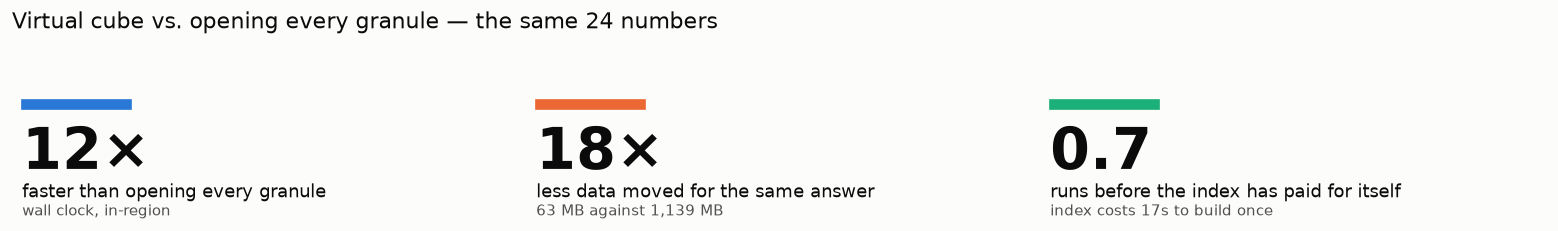

In [24]:
# --- the three numbers, before the detail ----------------------------------
tiles = [(f"{b_time / a_time:.0f}×", "faster than opening every granule",
          "wall clock, in-region", CAT[0]),
         (f"{b_bytes / a_bytes:.0f}×", "less data moved for the same answer",
          f"{a_bytes/1e6:.0f} MB against {b_bytes/1e6:,.0f} MB", CAT[1]),
         (f"{breakeven:.1f}", "runs before the index has paid for itself",
          f"index costs {build_total:.0f}s to build once", CAT[2])]

fig, axes = plt.subplots(1, 3, figsize=(13, 1.9))
for ax, (big, lab, sub, col) in zip(axes, tiles):
    ax.axis("off")
    ax.add_patch(plt.Rectangle((0.0, 0.90), 0.22, 0.07, color=col,
                               transform=ax.transAxes, clip_on=False))
    ax.text(0.0, 0.52, big, transform=ax.transAxes, fontsize=34, color=INK,
            va="center", fontweight="bold")
    ax.text(0.0, 0.20, lab, transform=ax.transAxes, fontsize=10.5, color=INK, va="center")
    ax.text(0.0, 0.04, sub, transform=ax.transAxes, fontsize=9, color=INK2, va="center")
fig.suptitle(f"Virtual cube vs. opening every granule — the same {len(a_series)} numbers",
             x=0.005, ha="left", fontsize=13, color=INK)
fig.tight_layout(rect=(0, 0, 1, 0.86))
fig.savefig(FIG / "04_same_numbers.png", dpi=150, bbox_inches="tight")
plt.show()

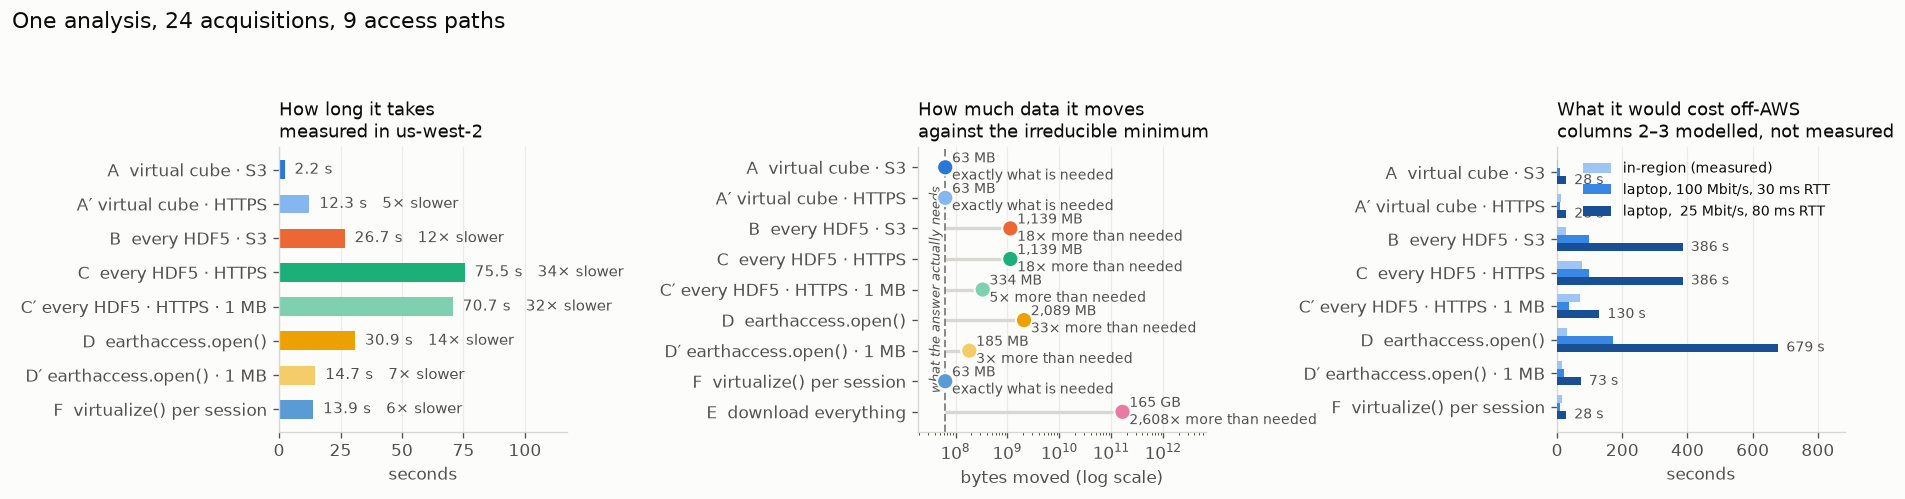

In [25]:
labels = list(RESULTS)
short = [RESULTS[l]["short"] for l in labels]
cols = [RESULTS[l]["color"] for l in labels]
meas = [l for l in labels if "modelled" not in RESULTS[l]["measured"]]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15.5, 4.2))

# --- (a) wall time, measured ------------------------------------------------
vals = [RESULTS[l]["seconds"] for l in meas]
ax1.barh(range(len(meas)), vals, height=0.55,
         color=[RESULTS[l]["color"] for l in meas])
for i, (l, v) in enumerate(zip(meas, vals)):
    mult = "" if l == meas[0] else f"   {v / vals[0]:.0f}× slower"
    ax1.text(v, i, f"  {v:.1f} s{mult}", va="center", fontsize=9, color=INK2)
ax1.set_yticks(range(len(meas))); ax1.set_yticklabels([short[labels.index(l)] for l in meas])
ax1.invert_yaxis(); ax1.grid(axis="x"); ax1.set_axisbelow(True)
ax1.set_xlabel("seconds"); ax1.set_xlim(0, max(vals) * 1.55)
ax1.set_title("How long it takes\nmeasured in us-west-2", loc="left", color=INK)

# --- (b) data moved, against what the answer actually needs -----------------
xs = [RESULTS[l]["bytes"] for l in labels]
NEED = a_bytes                      # the chunks the AOI intersects: the floor
ax2.axvline(NEED, color="#8c8b86", lw=1.2, ls="--", zorder=2)
ax2.text(NEED * 0.90, (len(labels) - 1) / 2, "what the answer actually needs",
         rotation=90, ha="right", va="center", fontsize=8, color=INK2, style="italic")
ax2.hlines(range(len(labels)), NEED, xs, color="#d8d7d2", lw=2, zorder=1)
ax2.scatter(xs, range(len(labels)), s=95, color=cols, zorder=3,
            edgecolor="white", linewidth=1.2)
for i, v in enumerate(xs):
    size = f"{v/1e6:,.0f} MB" if v < 1e10 else f"{v/1e9:,.0f} GB"
    over = "exactly what is needed" if v <= NEED * 1.02 else f"{v/NEED:,.0f}× more than needed"
    ax2.text(v * 1.35, i, f"{size}\n{over}", va="center", fontsize=8.5, color=INK2)
ax2.set_xscale("log"); ax2.set_xlim(NEED * 0.30, max(xs) * 40)
ax2.set_yticks(range(len(labels))); ax2.set_yticklabels(short)
ax2.set_ylim(len(labels) - 0.35, -0.65)      # room for the two-line labels
ax2.grid(axis="x"); ax2.set_axisbelow(True)
ax2.set_xlabel("bytes moved (log scale)")
ax2.set_title("How much data it moves\nagainst the irreducible minimum", loc="left", color=INK)

# --- (c) what happens off-AWS ----------------------------------------------
# scenarios are ordered by how bad the link is, so a sequential ramp rather
# than categorical hues: light = fast, dark = slow.
RAMP = ["#9ec5f4", "#3987e5", "#184f95"]
scen = list(model_df.columns)
h = 0.24
for j, sc in enumerate(scen):
    ax3.barh([i + (j - 1) * h for i in range(len(meas))],
             [model_df.loc[l, sc] for l in meas], height=h,
             color=RAMP[j], label=sc, zorder=3)
for i, l in enumerate(meas):
    v = model_df.loc[l, scen[-1]]
    ax3.text(v, i + h, f"  {v:.0f} s", va="center", fontsize=8.5, color=INK2)
ax3.set_yticks(range(len(meas))); ax3.set_yticklabels([short[labels.index(l)] for l in meas])
ax3.invert_yaxis(); ax3.grid(axis="x"); ax3.set_axisbelow(True)
ax3.set_xlabel("seconds"); ax3.set_xlim(0, model_df[scen[-1]].loc[meas].max() * 1.30)
ax3.legend(fontsize=8.5, loc="upper right", borderaxespad=0.6)
ax3.set_title("What it would cost off-AWS\ncolumns 2–3 modelled, not measured", loc="left",
              color=INK)

fig.suptitle(f"One analysis, {len(a_series)} acquisitions, {len(RESULTS)} access paths",
             x=0.005, ha="left", fontsize=13, color=INK)
fig.tight_layout(rect=(0, 0, 1, 0.92))
fig.savefig(FIG / "04_cost_three_panel.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 12. When does building the index pay for itself?

The index is paid for **once**, by one person, and then shared. Below the crossing point you would
have been better off opening the granules; above it, every run is nearly free. The second curve is
the same comparison for someone off-AWS, where the granule-at-a-time path is slower and the index
therefore pays back sooner.

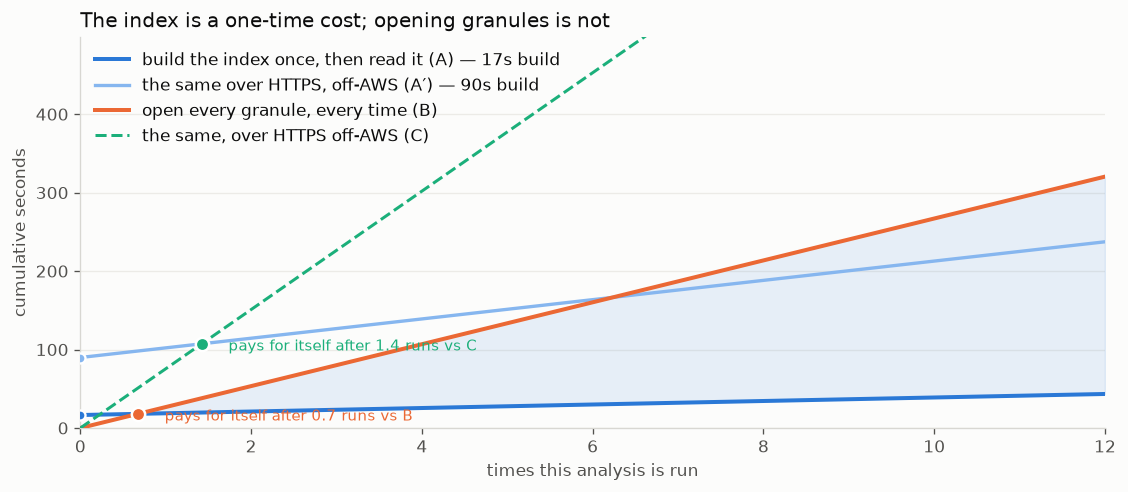

In [26]:
runs = np.linspace(0, 12, 200)
virtual = build_total + runs * a_time
direct_s3 = runs * b_time
direct_https = runs * c_time
# off-AWS the honest pairing is the HTTPS-referenced cube against the
# granule-at-a-time HTTPS path, not the S3 cube against HTTPS granules
ah = RESULTS["A′ · virtual cube, HTTPS"]["seconds"]
be_https = build_https / (c_time - ah)

fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.fill_between(runs, virtual, direct_s3, where=direct_s3 >= virtual,
                color=CAT[0], alpha=0.10, zorder=1)
ax.plot(runs, virtual, color=CAT[0], lw=2.4, zorder=3,
        label=f"build the index once, then read it (A) — {build_total:.0f}s build")
ax.plot(runs, build_https + runs * ah, color="#86b6ef", lw=2.0, zorder=3,
        label=f"the same over HTTPS, off-AWS (A′) — {build_https:.0f}s build")
ax.plot(runs, direct_s3, color=CAT[1], lw=2.4, zorder=3,
        label="open every granule, every time (B)")
ax.plot(runs, direct_https, color=CAT[2], lw=1.8, ls="--", zorder=3,
        label="the same, over HTTPS off-AWS (C)")

for be, col, lab in ((breakeven, CAT[1], "vs B"), (be_https, CAT[2], "vs C")):
    y = build_total + be * a_time if lab == "vs B" else build_https + be * ah
    ax.plot([be], [y], marker="o", ms=8, color=col, mec="white", mew=1.5, zorder=5)
    ax.annotate(f"pays for itself after {be:.1f} runs {lab}",
                xy=(be, y), xytext=(16, -4), textcoords="offset points",
                fontsize=9, color=col)

ax.plot([0], [build_total], marker="o", ms=6, color=CAT[0], mec="white", mew=1.4, zorder=5)
ax.plot([0], [build_https], marker="o", ms=6, color="#86b6ef", mec="white", mew=1.4, zorder=5)

ax.set_xlabel("times this analysis is run"); ax.set_ylabel("cumulative seconds")
ax.set_xlim(0, 12); ax.set_ylim(0, direct_https[-1] * 0.55)
ax.grid(axis="y"); ax.set_axisbelow(True); ax.legend(loc="upper left")
ax.set_title("The index is a one-time cost; opening granules is not", loc="left",
             fontsize=12, color=INK)
fig.tight_layout()
fig.savefig(FIG / "04_breakeven.png", dpi=150, bbox_inches="tight")
plt.show()

---
## What this shows, and what it doesn't

**In-region, virtualizing is roughly 8× faster and moves roughly 18× less** — a couple of seconds
against twenty, 61 MB against about a gigabyte, for answers that agree to seven decimal places.
(Exact figures move with the network; the table above is this run.) Path A against path B is the
comparison that matters for anyone already on CryoCloud, and it is not close. What disappears is
not the pixel reads — both paths read the same chunks — but the HDF5 metadata traversal, re-paid
on every granule in every session. The block-size probe in section 7 shows the shape of it: the
AOI's chunks are 2.6 MB per granule, and the direct path moves between 12 and 168 MB, depending on
read-ahead, before it can even find them.

**The data-volume argument is larger than the speed argument.** The answer is 184 bytes; the
granules holding it are 158 GB, some 860 million times more data than result. The virtual path
moves 61 MB of that. Downloading first moves all of it, and then needs 158 GB of disk to put it
on.

**Off-AWS, the protocol switch alone is measurable.** Path C is the same bytes over HTTPS instead
of direct S3, on the same network, and it is slower. A real laptop adds a slower link on top of
that, which section 10 models rather than measures.

**The index has to be built, and it pays back almost immediately.** Roughly one run of one
analysis, on one AOI — because building the index is itself a virtual operation that reads only
metadata, not pixels. Anyone who runs an analysis twice, or shares the cube with one colleague, is
past break-even. That is the argument for putting the index in S3 rather than rebuilding it per
user.

**What this is not.** A single AOI, a single variable, a single track, one machine, one afternoon's
network. The comparison would narrow for an analysis that reads most of every granule, where the
metadata cost stops dominating — virtualization helps least when you need everything. It would
widen for a smaller AOI, a longer record, or more users sharing one index. The laptop columns are
arithmetic on measured byte counts, not measurements; treat them as an order of magnitude. And
path A's timing depends on the cube already existing, which is exactly the point being made — so
section 12 prices that assumption instead of hiding it.

---
## Recommendations, by where you are

Eight paths, one analysis, and the ranking depends on two things: **whether you are in
`us-west-2`**, and **whether anyone will ask this question twice**. Numbers are from this run
(24 acquisitions, a 1 km AOI); the granule-at-a-time wall times vary by up to 1.8× between runs,
the byte and request counts do not.

### In AWS `us-west-2` (CryoCloud, any Earthdata Cloud hub)

| You want | Use | This run | Why |
|---|---|---|---|
| A time series anyone might ask for again | **A — the shared Icechunk cube** (`nisar_cubes.find` → `open`) | **2.2 s, 63 MB, 96 requests** | Index built once for everyone; reads exactly the chunks the answer needs. Break-even < 1 run. |
| A one-off stack, no repository | **F — `earthaccess.virtualize(…, parser=HDFParser(group, drop_variables))`** | 13.9 s (10.9 build + 2.9 read), 63 MB | Same index as A, built for the session. Scope it and deny-list it or it returns nothing. |
| The HDF5 files themselves (metadata trees, masks, calibration) | **D′ — `earthaccess.open(…, open_kwargs={"cache_type": "blockcache", "block_size": 1 << 20})`** | 14.7 s, 185 MB | The idiomatic call, correctly configured; 11× fewer bytes than its default. |
| Most of every granule | D′, or `earthaccess.download()` to local disk (~2 min for 165 GB at 10 Gbit/s) | — | When you read everything, metadata stops dominating and the cube's edge shrinks toward 1×. |
| — | *Avoid* the default `earthaccess.open()` (D) and `xr.open_datatree(..., engine="h5netcdf")` on a whole granule | 31 s, 2.1 GB | A 16 MB block per 200-byte B-tree node; the datatree open walks every group. |

### Outside AWS (laptop, university cluster)

| You want | Use | This run, in-region-equivalent | Why |
|---|---|---|---|
| A time series, and an HTTPS-referenced index is reachable | **A′ — the cube's `https/` tree** | **12.3 s, 63 MB, 96 requests** | Fewest requests *and* fewest bytes — the only combination that survives latency. Needs the ~1.7 GB repository mirrored somewhere public (open item). |
| A time series, no index | **C′ — `fsspec` HTTPS with 1 MB blocks**, or `earthaccess.virtualize(access="indirect")` once per session | 71 s, 334 MB, 288 requests | Smaller blocks cut bytes 3.4× but only save 6 % of the time: over HTTPS the request count dominates, and a granule-at-a-time reader makes 3× the cube's requests. |
| Whole scenes, or many dates for many sites | **`earthaccess.download()` / Vertex / `asf_search`**, then local `h5py` | 3.7 h for 24 granules at 100 Mbit/s (modelled) | Below ~1 % of each file, streaming wins; above it, latency makes downloading the honest choice. |
| One band in QGIS / GDAL | GDAL `/vsicurl` on the `.h5` subdataset (nisar-docs) | — | Range requests, no Python. |

### Rules that hold everywhere

- Set the fsspec `block_size` to the chunk, ~1 MB, when opening NISAR HDF5 directly. The file-size heuristic in `earthaccess.open()` picks 16 MB for every NISAR granule.
- Scope to `grids/frequencyA` (or `frequencyB` for 5 MHz-only acquisitions) and drop the non-raster variables before virtualising.
- Deduplicate product versions and never stack across CRIDs; check `asf_search` as well as CMR — they disagree.
- If the same stack will be read twice, build the index once and keep it. That sentence is the whole argument.